In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from signaturesnet.modules.signet_module import SigNet
import seaborn as sns
import matplotlib.colors as mcolors
from collections import defaultdict
import os
from scipy.stats import ttest_ind
import matplotlib.colors as mcolors

plt.rcParams["font.family"] = "Helvetica Neue"

Functions

In [2]:
def build_spectrum(df):
    bases = ['A', 'C', 'G', 'T']
    mutations = ['C>A', 'C>G', 'C>T', 'T>A', 'T>C', 'T>G']
    
    full_96_cols = [
        f"{left}[{mut}]{right}" 
        for left in bases 
        for mut in mutations 
        for right in bases
    ]
    
    sdf = df.groupby(["Sample", "Type"]).size().reset_index(name="counts")    
    qdf = sdf.pivot(index="Sample", columns="Type", values="counts")
    qdf = qdf.reindex(columns=full_96_cols, fill_value=0)
    
    return qdf.fillna(0).astype(int)

def annotate_info(df, nature):
    df["Samples"] = df.Samples.astype(str)
    sdf = df[df.Samples.isin(nature.keys())]
    ndf = sdf.Samples.apply(lambda x: pd.Series(nature[x].values()))
    ndf.columns = ["ctype", "drug", "dose"]
    return pd.concat([sdf, ndf], axis=1)


def run_mw(df):
    return mannwhitneyu(
        df.query("drug=='nodrug'").SBS5, 
        df.query("drug!='nodrug'").SBS5,
        alternative='less'
        ).pvalue

def run_ttest(df):
    group1 = df.query("drug=='nodrug'").SBS5
    group2 = df.query("drug!='nodrug'").SBS5
    
    # equal_var=False makes it a Welch's T-test
    return ttest_ind(group1, group2, equal_var=False, alternative='less').pvalue

def multinomial_subsample(df, f):

    def sample_row(row):
        n_total = row.sum()
        if n_total == 0:
            return row
        
        probabilities = row.values / n_total        
        n_sub = int(np.floor(f * n_total))
        counts_sub = np.random.multinomial(n_sub, probabilities)
        
        return pd.Series(counts_sub, index=row.index)

    return df.apply(sample_row, axis=1)

def downsample_row_strictly(row, f):
    n_total = row.sum()
    if n_total == 0:
        return row
    
    n_sub = int(np.floor(f * n_total))
    categories = np.repeat(row.index, row.values)
    sampled_indices = np.random.choice(len(categories), size=n_sub, replace=False)
    sampled_categories = categories[sampled_indices]
    
    return pd.Series(sampled_categories).value_counts().reindex(row.index, fill_value=0)

def downsample(df, f):
    return df.apply(lambda row: downsample_row_strictly(row, f), axis=1)

Load mutations

In [3]:
def load_mutations(study):
    muts = pd.read_csv(f"../data/{study}/{study}.csv.gz")
    spec = build_spectrum(muts)
    spec = spec.transpose().fillna(0)
    return spec

hwang_spec = load_mutations("Hwang2025")
kucab_spec = load_mutations("Kucab2019")
szirk_spec = pd.read_csv("../data/Szikriszt2021/Szikriszt2021.spec.csv", index_col=0)
potis_spec = load_mutations("Poti2022")

Load metadata

In [4]:
hwang_meta = pd.read_csv("../data/Hwang2025/Hwang2025.tab.gz", sep="\t")
kucab_meta = pd.read_csv("../data/Kucab2019/Kucab2019.tab.gz", sep="\t")
szirk_meta = pd.read_csv(f"../data/Szikriszt2021/Szikriszt2021_cosmic/Assignment_Solution/Activities/Assignment_Solution_Activities.txt",sep="\t")

Signature contributions

In [5]:
from SigProfilerAssignment import Analyzer as Analyze

studies = ["Kucab2019", "Hwang2025", "Poti2022", "Szikriszt2021"]
dats = [kucab_spec, hwang_spec, potis_spec, szirk_spec]
for study,spec in zip(studies, dats):
    outdir = f"sigprofiler_assignment/{study}"
    os.makedirs(outdir, exist_ok=True)
    Analyze.cosmic_fit(spec, outdir,cosmic_version=3.1, export_probabilities=False, make_plots=False)

cmpx_str = "Assignment_Solution/Activities/Assignment_Solution_Activities.txt"
kucab_sp = pd.read_csv(f"sigprofiler_assignment/Kucab2019/{cmpx_str}",sep="\t")
hwang_sp = pd.read_csv(f"sigprofiler_assignment/Hwang2025/{cmpx_str}",sep="\t")
szirk_sp = pd.read_csv(f"sigprofiler_assignment/Szikriszt2021/{cmpx_str}",sep="\t")
potis_sp = pd.read_csv(f"sigprofiler_assignment/Poti2022/{cmpx_str}",sep="\t")

sigs = [s for s in kucab_sp.columns if s.startswith("SBS")]

%matplotlib inline 

Assigning COSMIC sigs or Signature Database ...... 
|████████████████████████████████████████| 324/324 [100%] in 19.9s (16.26/s) 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
Assigning COSMIC sigs or Signature Database ...... 
|████████████████████████████████████████| 28/28 [100%] in 2.2s (12.80/s) 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
Assigning COSMIC sigs or Signature Database ...... 
|████████████████████████████████████████| 6/6 [100%] in 0.5s (13.06/s) 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
Assigning COSMIC sigs or Signature Database ...... 
|████████████████████████████████████████| 47/47 [100%] in 3.0s (15.50/s) 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 


In [6]:
def run_signet(spec):
    # Define Signatures
    sigs_sg = ("SBS1 SBS2 SBS3 SBS4 SBS5 SBS6 SBS7a SBS7b SBS7c SBS7d SBS8 SBS9 "
            "SBS10a SBS10b SBS11 SBS12 SBS13 SBS14 SBS15 SBS16 SBS17a SBS17b "
            "SBS18 SBS19 SBS20 SBS21 SBS22 SBS23 SBS24 SBS25 SBS26 SBS27 SBS28 "
            "SBS29 SBS30 SBS31 SBS32 SBS33 SBS34 SBS35 SBS36 SBS37 SBS38 SBS39 "
            "SBS40 SBS41 SBS42 SBS43 SBS44 SBS45 SBS46 SBS47 SBS48 SBS49 SBS50 "
            "SBS51 SBS52 SBS53 SBS54 SBS55 SBS56 SBS57 SBS58 SBS59 SBS60 SBS84 "
            "SBS85 SBS86 SBS87 SBS88 SBS89 SBS90 Unknown").split()
    signet = SigNet()
    mtrx = spec.transpose()
    res_obj = signet(mutation_dataset=mtrx)
    w, l, u, c, _ = res_obj.get_output()
    res = pd.DataFrame(w, columns=[f"f{s}" for s in sigs_sg])
    res["Samples"] = mtrx.index
    res["nTotal"] = mtrx.sum(axis=1).values
    for s in sigs_sg:
        res[s] = res[f"f{s}"]*res["nTotal"]
    return res

kucab_sg = run_signet(kucab_spec)
hwang_sg = run_signet(hwang_spec)
szirk_sg = run_signet(szirk_spec)
potis_sg = run_signet(potis_spec)

Annotate info

In [7]:
nature = defaultdict()

# Kucab
for _,r in kucab_meta.iterrows():
    drug = "-".join(r.Status.split("-")[1:-1]).replace("mutagen:", "")
    drug = "nodrug" if "Control" in drug or "control" in drug else drug
    dose = float(r.Status.split("-")[-1].split(":")[-1].split()[0])
    nature[r.Sample] = {"CellType":r.Tissue_CellType, "drug":drug, "dose":dose}

# Hwang
for _,r in hwang_meta.iterrows():
    drug = r.Status.split("-")[-1]
    ctype = r.Tissue_CellType
    if ctype!="HAP1": continue
    if drug.startswith("c"):
        continue
    if drug=="nodrug":
        dose = np.nan
    else:
        dose = float(r.Status.split("-")[-2].replace("microM", ""))
    nature[r.Sample] = {"CellType":ctype, "drug":drug, "dose":dose}

# Szirk
for sam in szirk_spec.columns:
    ctype = sam.split("_")[0]
    drug = sam.split("_")[-2]
    if ctype!="TK6": continue
    if drug=="mock":
        nature[sam] = {"CellType":ctype, "drug":"nodrug", "dose":np.nan}
    if "platin" in drug:
        dose = float(sam.split("_")[2].replace("uM", "").replace(",", "."))
        nature[sam] = {"CellType":ctype, "drug":drug, "dose":dose}

# Poti
for sam in potis_spec.columns:
    ctype = sam.split("_")[0]
    drug = sam.split("_")[-2]
    if drug=="mock":
        nature[sam] = {"CellType":ctype, "drug":"nodrug", "dose":np.nan}
    if "platin" in drug:
        dose = np.nan
        nature[sam] = {"CellType":ctype, "drug":drug, "dose":dose}

In [8]:
kucab_spf = annotate_info(kucab_sp, nature)
hwang_spf = annotate_info(hwang_sp, nature)
szirk_spf = annotate_info(szirk_sp, nature)
potis_spf = annotate_info(potis_sp, nature)

kucab_sgf = annotate_info(kucab_sg, nature)
hwang_sgf = annotate_info(hwang_sg, nature)
szirk_sgf = annotate_info(szirk_sg, nature)
potis_sgf = annotate_info(potis_sg, nature)

Downsampling

In [10]:
from SigProfilerAssignment import Analyzer as Analyze
sel_sigs = ['SBS1', 'SBS16', 'SBS21', 'SBS40', 'SBS18', 'SBS5', 'SBS11']
qdf = hwang_spec[hwang_spf.Samples.tolist()].transpose()

resamp_l = []
for f in np.linspace(0.05, 1, 101):
    spec_l = []
    for i in range(100):
        sdf = downsample(qdf, f)
        sdf = sdf.reset_index()
        sdf["Sample"] = sdf["Sample"]+":"+str(f)+":"+str(i)
        sdf = sdf.set_index("Sample")
        fdf = sdf.transpose().fillna(0)
        spec_l.append(fdf)

    print(f"RUNNING {f}")
    sres = pd.concat(spec_l, axis=1)
    outdir = f"sigprofiler_assignment/resamp_smalldown_{f}"
    os.makedirs(outdir, exist_ok=True)
#    Analyze.cosmic_fit(sres, outdir, signatures=sel_sigs, cosmic_version=3.1, export_probabilities=False, make_plots=False)
    Analyze.cosmic_fit(sres, outdir, cosmic_version=3.1, export_probabilities=False, make_plots=False)
    resamp = pd.read_csv(f"{outdir}/Assignment_Solution/Activities/Assignment_Solution_Activities.txt",sep="\t")
    resamp_l.append(resamp)

%matplotlib inline 

resamp = pd.concat(resamp_l)
info = resamp.Samples.str.split(":", expand=True)
resamp = resamp.drop("Samples", axis=1)
info.columns = ["Samples", "frac", "rep"]
resamp = pd.concat([info, resamp], axis=1)
resamp = annotate_info(resamp, nature)
resamp = resamp.fillna(0)

RUNNING 0.05
Assigning COSMIC sigs or Signature Database ...... 
|████████████████████████████████████████| 900/900 [100%] in 56.9s (15.82/s) 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
RUNNING 0.059500000000000004
Assigning COSMIC sigs or Signature Database ...... 
|████████████████████████████████████████| 900/900 [100%] in 56.3s (15.98/s) 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
RUNNING 0.069
Assigning COSMIC sigs or Signature Database ...... 
|████████████████████████████████████████| 900/900 [100%] in 58.1s (15.49/s) 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
RUNNING 0.0785
Assigning COSMIC sigs or Signature Database ...... 
|████████████████████████████████████████| 900/900 [100%] in 58.8s (15.31/s) 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
RUNNING 0.088
Assigning COSMIC sigs or Signature Database ...... 
|██

In [11]:
mres_l = []
sigs = [s for s in resamp.columns if s.startswith("SBS")]
for (frac,rep), df in resamp.groupby(["frac", "rep"]):
#    pval = run_mw(df) 
    pval = run_ttest(df) 
    mres_l.append([f"{float(frac):.2f}", rep, pval, df["SBS5"].mean(), df["SBS5"].sum()])

mres = pd.DataFrame(mres_l)
mres.columns = ["frac", "rep", "pval", "sbs5_mean", "sbs5_total"]
mres["log_pval"] = -np.log10(mres.pval)

th = 0.05
fres = mres.groupby("frac").agg({
    "pval": lambda x: (x < th).mean(),
    "sbs5_total": "mean",
    "sbs5_mean": "mean"
}).rename(columns={"pval": "sign"}).reset_index()

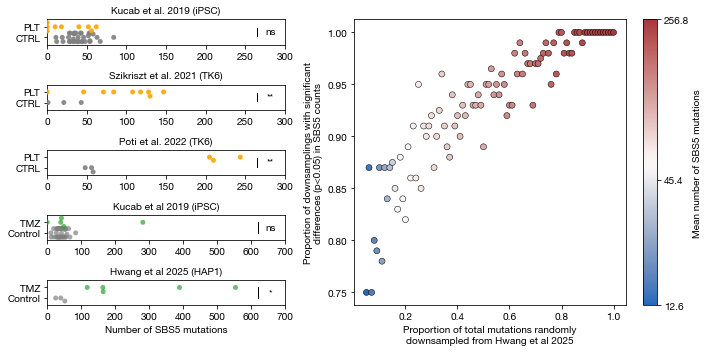

In [14]:
mosaic = '''
FFFCCCC
DDDCCCC
EEECCCC
AAACCCC
BBBCCCC
'''

fig, axs = plt.subplot_mosaic(mosaic, figsize=[10,5])
studies = ["Kucab et al 2019 (iPSC)", "Hwang et al 2025 (HAP1)"]
kucab_spf_tmz = kucab_spf[(kucab_spf.drug.str.contains("emozolo")) | (kucab_spf.drug.str.contains("nodrug"))]
dats = [
    kucab_spf_tmz,
    hwang_spf
]

for dat,let,study in zip(dats, ["A", "B"], studies):
    ax = axs[let]
    pval1 = run_ttest(dat)
    pval2 = run_mw(dat)
    star = "ns"
    if pval1<0.05:
        star="*"
        if pval1<0.005:
            star="**"
    sns.swarmplot(
        data=dat, x="SBS5", y="drug", 
        hue="drug", palette={"TMZ":"C2", "Temozolomide":"C2", "nodrug":"gray"},
        alpha = 0.7,
        legend=False, ax=ax)
    # f"{pval1:.3f}"
    ax.annotate(
        star, xy=(0.94, 0.5), xycoords="axes fraction", 
        va="center", ha="center"
        )
    ax.plot((620,620),(0,1), color="black", lw=1)
#    ax.axvline(dat.SBS5.mean(), color="gray", ls="dashed")
    ax.set_xlim([0, 700])
    ax.set_ylim([-0.7, 1.7])
    ax.set_xlabel("")
    ax.set_yticklabels(["Control", "TMZ"])
    ax.set_ylabel("")
    ax.set_title(study, fontsize=10)

studies = [
    "Kucab et al. 2019 (iPSC)", 
    "Szikriszt et al. 2021 (TK6)", 
    "Poti et al. 2022 (TK6)"
    ]
dats = [
    kucab_spf[(kucab_spf.drug.str.contains("plat")) | (kucab_spf.drug.str.contains("nodrug"))], 
    szirk_spf, 
    potis_spf
    ]
for dat,let,study in zip(dats, ["F", "D", "E"], studies):
    ax = axs[let]
    pval1 = run_ttest(dat)
    pval2 = run_mw(dat)
    sign = "" # if pval>0.05 else "*"
    dat["rename_drug"] = ["Control" if x=="nodrug" else "PLT" for x in dat.drug]
    dat["cap_drug"] = [x.capitalize() if x!="nodrug" else "Control" for x in dat.drug]
    sns.swarmplot(
        data=dat, x="SBS5", y="rename_drug", 
        order = ["Control", "PLT"],
        hue="cap_drug", palette = {"Control":"gray", "Cisplatin":"orange", "Carboplatin":"orange", "Oxaliplatin":"orange"},
        alpha = 0.9, legend=False if let!="B" else True,
        ax=ax)
    star = "ns"
    if pval1<0.05:
        star="*"
        if pval1<0.005:
            star="**"
    ax.annotate(
        star, xy=(0.94, 0.5), xycoords="axes fraction", 
        va="center", ha="center", fontsize=10,
        )
    ax.plot((265,265),(0.1,0.9), color="black", lw=1)
    ax.set_xlim([0, 300])
    ax.set_ylim([-0.7, 1.7])
    ax.set_xlabel("")
    ax.set_yticklabels(["CTRL", "PLT"])
    ax.set_ylabel("")
    ax.set_title(study, fontsize=10)

axs["B"].set_xlabel("Number of SBS5 mutations")

fres["frac"] = fres.frac.astype(float)
norm = mcolors.TwoSlopeNorm(
    vcenter=50, 
    vmin=fres["sbs5_mean"].min(), 
    vmax=fres["sbs5_mean"].max()
)
points = axs["C"].scatter(
    data=fres, x="frac", y="sign", 
    c=fres["sbs5_mean"], cmap="vlag", 
    norm=norm, edgecolor="black", linewidth=0.5
)

# 3. Add the colorbar
cbar = plt.colorbar(points, ax=axs["C"])
cbar.set_label("Mean number of SBS5 mutations")
cbar.set_ticks([fres["sbs5_mean"].min(), kucab_spf_tmz.SBS5.mean(), fres["sbs5_mean"].max()])

axs["C"].set_xlabel("Proportion of total mutations randomly\ndownsampled from Hwang et al 2025")
axs["C"].set_ylabel("Proportion of downsamplings with significant\ndifferences (p<0.05) in SBS5 counts")

plt.tight_layout()
plt.savefig("pdfs/hwang_2025_downsampling_ttest.pdf")
plt.savefig("pdfs/hwang_2025_downsampling_ttest.jpg", dpi=400)